# Emotion Classification with RNNs, LSTMs & GRUs

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU**.

## 1. Import Libraries
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset

c:\Users\zahee\miniconda3\envs\ai-ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset
Load the `dair-ai/emotion` dataset from Hugging Face.
https://huggingface.co/datasets/dair-ai/emotion

In [3]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

In [4]:
label_names=emotion_dataset['train'].features['label'].names

In [5]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
df_train=pd.DataFrame(
    {
        'text':train_text,
        'label':[label_names[i] for i in train_label]
    }
)

df_test=pd.DataFrame(
    {
        'text':test_text,
        'lebel':[label_names[i] for i in test_label]
    }
)

In [7]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [8]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='str', name='label')

<Axes: xlabel='label', ylabel='count'>

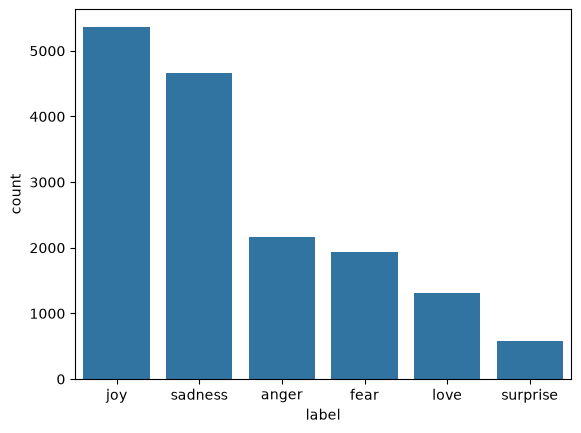

In [9]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)

In [10]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


## 4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words=10000

tokenizer=Tokenizer(num_words=max_words,oov_token='<uk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence=tokenizer.texts_to_sequences(df_train['text'])
test_sequence=tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence=pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence=pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

train_labels=np.array(train_label)
test_labels=np.array(test_label)

num_classes=len(np.unique(train_label))
num_classes

print(f"Vocabulary Size : {len(tokenizer.word_index)}")
print(f"The Sentence Length : {padded_train_sequence.shape[1]}")

Vocabulary Size : 15213
The Sentence Length : 50


## 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

In [13]:
from sklearn.utils import class_weight

class_weights=class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict=dict(enumerate(class_weights))

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stoping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

### 6.1 Model 1 — Simple RNN
Plain unrolled Recurrent Neural Network.

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Embedding,Dense,Dropout,LSTM,GRU

rnn_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [24]:
rnn_model.fit(padded_train_sequence,
              train_labels,
              validation_data=(padded_test_sequence,test_labels),
              epochs=20,
              batch_size=32,
              class_weight=class_weight_dict,
              callbacks=[early_stoping]  

              )
rnn_loss,rnn_accuracy=rnn_model.evaluate(padded_test_sequence,test_labels)
print(f"RNN Loss : {rnn_loss}")
print(f"RNN Accuracy : {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.1632 - loss: 1.9312 - val_accuracy: 0.1705 - val_loss: 1.7859
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.1549 - loss: 1.8091 - val_accuracy: 0.2345 - val_loss: 1.7705
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.1565 - loss: 1.7858 - val_accuracy: 0.1445 - val_loss: 1.7843
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1452 - loss: 1.7808 - val_accuracy: 0.1010 - val_loss: 1.7915
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.1447 - loss: 1.7693 - val_accuracy: 0.1020 - val_loss: 1.7950
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2345 - loss: 1.7705
RNN Loss : 1.7704931497573853
RNN Accuracy : 0.2345000058412552


### 6.2 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [22]:
lstm_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    LSTM(units=128,return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stoping]
    )

lstm_loss,lstm_accuracy=lstm_model.evaluate(padded_test_sequence,test_labels)
print(f"LSTM Loss : {lstm_loss}")
print(f"LSTM Accuracy : {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.1441 - loss: 1.7947 - val_accuracy: 0.0375 - val_loss: 1.8222
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.1560 - loss: 1.7923 - val_accuracy: 0.0415 - val_loss: 1.7863
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.2233 - loss: 1.7319 - val_accuracy: 0.2230 - val_loss: 1.7195
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.3652 - loss: 1.4673 - val_accuracy: 0.5155 - val_loss: 1.3175
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.5965 - loss: 0.9698 - val_accuracy: 0.5865 - val_loss: 1.0672
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.7952 - loss: 0.5843 - val_accuracy: 0.7790 - val_loss: 0.6867
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8639 - loss: 0.4131 - val_accuracy: 0.8415 - val_loss: 0.5398
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8945 - loss: 0.3355 - 

### 6.3 Model 3 — Standard GRU
Plain stacked Gated Recurrent Unit network.

In [25]:
gru_model=Sequential([
    Embedding(input_dim=max_words,output_dim=128,input_length=50),
    GRU(units=128,return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stoping]
    )
gru_loss,gru_accuracy=gru_model.evaluate(padded_test_sequence,test_labels)
print(f"GRU Loss : {gru_loss}")
print(f"GRU Accuracy : {gru_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.1622 - loss: 1.7961 - val_accuracy: 0.3480 - val_loss: 1.7573
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1553 - loss: 1.7953 - val_accuracy: 0.2905 - val_loss: 1.7613
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.1647 - loss: 1.7941 - val_accuracy: 0.1395 - val_loss: 1.7878
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1534 - loss: 1.7943 - val_accuracy: 0.0830 - val_loss: 1.8156
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3480 - loss: 1.7573
GRU Loss : 1.7572969198226929
GRU Accuracy : 0.3479999899864197


In [26]:
result_df=pd.DataFrame({
    'Model':['RNN','LSTM','GRU'],
    'Test Loss':[rnn_loss,lstm_loss,gru_loss],
    'Test Accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]
}).sort_values(by='Test Accuracy',ascending=False)

result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.442988,0.8755
2,GRU,1.757297,0.3480
0,RNN,1.770493,0.2345


## 7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

### 7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [27]:
from tensorflow.keras.layers import Bidirectional


BIGRU_model=Sequential([
    Embedding(input_dim=max_words,output_dim=300,input_length=50),
    Bidirectional(GRU(units=128,return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes,activation='softmax')
])

BIGRU_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
BIGRU_model.summary()

c:\Users\zahee\miniconda3\envs\ai-ml\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
BIGRU_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence,test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stoping]
    )


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.5976 - loss: 1.0092 - val_accuracy: 0.9015 - val_loss: 0.3563
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.9215 - loss: 0.2238 - val_accuracy: 0.9280 - val_loss: 0.1684
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9426 - loss: 0.1592 - val_accuracy: 0.9215 - val_loss: 0.2155
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.9574 - loss: 0.1141 - val_accuracy: 0.9205 - val_loss: 0.2189
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.9694 - loss: 0.0851 - val_accuracy: 0.9230 - val_loss: 0.2832


In [29]:
BIGRU_loss,BIGRU_accuracy=BIGRU_model.evaluate(padded_test_sequence,test_labels)
print(f"BIGRU Loss : {BIGRU_loss}")
print(f"BIGRU Accuracy : {BIGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9280 - loss: 0.1684
BIGRU Loss : 0.16844233870506287
BIGRU Accuracy : 0.9279999732971191


## 8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

### 8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step


<Axes: >

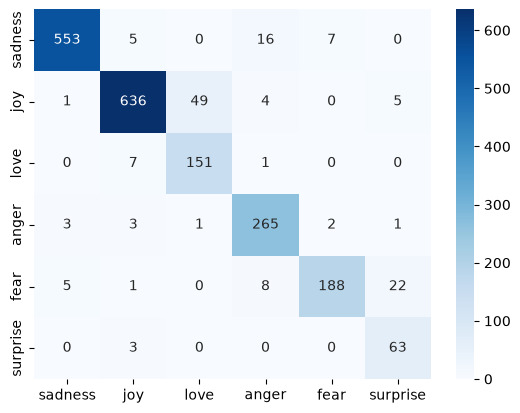

In [31]:
from sklearn.metrics import confusion_matrix

BIGRU_Predictions=np.argmax(BIGRU_model.predict(padded_test_sequence),axis=1)
sns.heatmap(confusion_matrix(test_label,BIGRU_Predictions),annot=True,fmt='d',cmap='Blues',xticklabels=label_names,yticklabels=label_names)

## 9. Final Predictions
Test the winning model on unseen sample sentences.

In [32]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]
sample_sequences=tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences=pad_sequences(sample_sequences,maxlen=50,padding='post',truncating='post')

sample_predictions=np.argmax(BIGRU_model.predict(sample_padded_sequences),axis=1)
for i in range(len(sample_texts)):
    print(f"TEXT : {sample_texts[i]}\n Prediction Emotion : {label_names[sample_predictions[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
TEXT : I can't believe how happy I am right now, this is amazing!
 Prediction Emotion : surprise
TEXT : I feel so alone and hopeless today.
 Prediction Emotion : sadness
TEXT : I am furious that they cancelled the trip at the last minute.
 Prediction Emotion : anger
TEXT : I feel terrified when walking down dark alleyways alone.
 Prediction Emotion : fear
TEXT : I was shocked and completely surprised by the unexpected gift!
 Prediction Emotion : surprise


## 10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [33]:
import os
import pickle

BIGRU_model.save('../Models/BIGRU_MODEL.keras')

with open('../Models/tokenizer.pkl','wb') as file:
    pickle.dump(tokenizer,file)